## Bethe-Bloch Simulation

In [1]:
import numpy as np
import scipy.constants as con

def beta(T: float, E_0: float):
    """
    :T: Kinetische Energie des Teilchens in eV
    :E_0: Ruheenergie des Teilchens in eV
    """
    gamma = (T/E_0)+1
    return np.sqrt(1-1/gamma**2)

class Material:
    def __init__(self, Z, A, I, n):
        """
        :Z: Ladungszahl
        :A: Massenzahl
        :I: mittlere Ionisationsenergy (in J)
        :n: Dichte in g/cm³
        """
        self.I = I
        self.n_e = Z*n*1e3/A/con.u
        self.rho = n

Au = Material(79, 197, 790*con.e, 19.32)
Si = Material(14, 28, 173*con.e, 2.33)

def Bethe(target: Material, E: float, z=2, E0=3728e6):
    """
    :target: Zielmaterial
    :E: Kinetische Energie des Teilchens in eV
    :z: Ladungszahl des Teilchens
    :E0: Ruheenergie des Teilchens in eV
    """
    n = target.n_e
    I = target.I
    B2 = beta(E, E0)**2
    #a = (4 * np.pi * n * z**2) / (con.m_e * con.c**2 * B2) # Henrik
    a = (4*np.pi*n*z**2)/(con.m_e*con.c**2*B2)
    #b = ((con.e**2) / (4 * np.pi * con.epsilon_0))**2 # Henrik
    b = (con.e**2/(4*np.pi*con.epsilon_0))**2
    #c = np.log((2 * con.m_e * con.c**2 * B2) / (I * (1 - B2))) - B2 # Henrik
    c = np.log((2*con.m_e*con.c**2*B2)/(I*(1-B2))) - B2
    return a * b * c #* 6.241509074460763e+18 * 1e-6 * 1e-2

def Bethe_old(target: Material, E:float, z=2, E0=3728e6):
    """
    :target: Zielmaterial
    :E: Kinetische Energie des Teilchens in eV
    :z: Ladungszahl des Teilchens
    :E0: Ruheenergie des Teilchens in eV
    """
    n = target.n_e
    I = target.I
    B2 = beta(E, E0)**2
    a = (4*np.pi*n*z**2)/(con.m_e*con.c**2*B2)
    b =(con.e**2/(4*np.pi*con.epsilon_0))**2
    c = np.log((2*con.m_e*con.c**2*B2)/(I*(1-B2))) - B2
    return a * b * c

def Reichweite(target: Material, E: float, dx=1e-6, Elim=1.0):
    """
    :target: Materialeigenschaften des Zielmaterials
    :E: Kinetische Energie des Teilchens in eV
    :dx: Schrittweite in m
    """
    l = 0
    while E > Elim: # in eV
        lost = Bethe(target, E) / con.e * dx # Energieverlust in eV
        E -= abs(lost)
        l += dx
    return l *100 * target.rho

In [4]:
E = np.logspace(3, 9, 1000, endpoint=True)

vBethe = np.vectorize(Bethe)
vReich = np.vectorize(Reichweite)

dEdx = Bethe(Si, E)
rw = []
for i in E:
    rw.append(Reichweite(Si, i, dx=1e-6))
rw = np.array(rw)

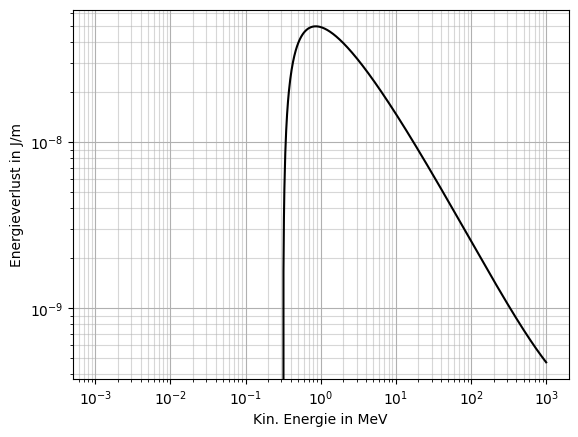

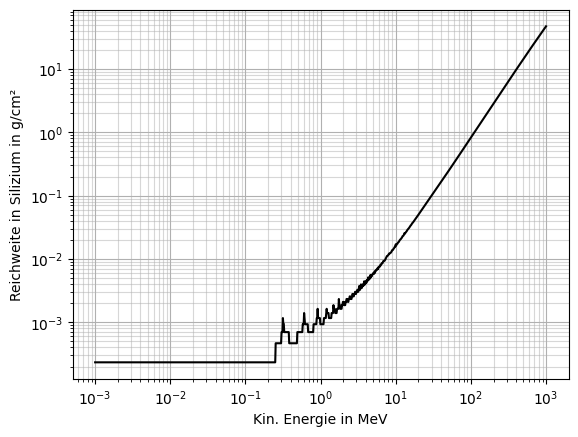

In [5]:
import matplotlib.pyplot as plt

plt.plot(E/1e6, dEdx, '-k')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('Energieverlust in J/m')
plt.xlabel('Kin. Energie in MeV')
plt.minorticks_on()
plt.grid(which='major')
plt.grid(which='minor', alpha=0.5)

fig, ax = plt.subplots()
ax.plot(E/1e6, rw, '-k')


ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Kin. Energie in MeV')
ax.set_ylabel('Reichweite in Silizium in g/cm²')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)


plt.show()

## Linearitätsprüfung

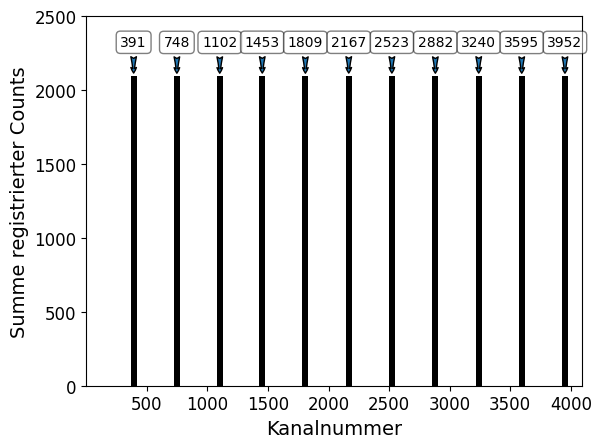

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

chans = []
sums = []

for file in os.listdir(r'../Messdaten/19012026_Halbleiter/3_neu/'):
    data = np.loadtxt(f'../Messdaten/19012026_Halbleiter/3_neu/{file}')
    ii = 0 # sum of all channels
    iii = 0 # number of channels
    xx = 0 # sum of all counts
    for i, x in enumerate(data):
        if i == 0 or i == 1: # skip live/real time channels
            continue
        if x > 0:
            iii += 1
            ii += i
            xx += x
    chans.append(int(ii/iii)+1)
    sums.append(xx)

fig, ax = plt.subplots()

for chan, sum in zip(chans, sums):
    ax.bar(chan, sum, width=50, color='k')
    ax.annotate(str(chan), (chan,sum), (chan, sum+200), arrowprops={'arrowstyle': 'fancy'}, ha='center', bbox={'boxstyle':'round', 'alpha':0.5, 'fc':'white', 'ec':'black'})

ax.set_xlabel("Kanalnummer", fontsize=14)
ax.set_ylabel("Summe registrierter Counts", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(1, 4096)
ax.set_ylim(0, 2500)
plt.show()

y=0.00140381(0.00000107) * x -0.0452(0.0026)


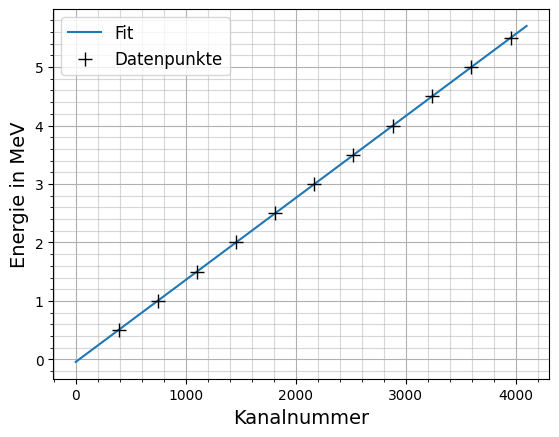

In [8]:
from scipy.stats import linregress
Energien = np.arange(0.5, 6., 0.5)

# fit
linfit = linregress(chans, Energien)
slope, sloperr, intercept, intercepterr = linfit.slope, linfit.stderr, linfit.intercept, linfit.intercept_stderr
print(f"y={slope:.8f}({sloperr:.8f}) * x {intercept:.4f}({intercepterr:.4f})")

x = np.arange(1, 4097)
plt.plot(x, slope*x+intercept)
for chan, E in zip(chans, Energien):
    plt.plot(chan, E, '+k', ms=10)
plt.xlabel("Kanalnummer", fontsize=14)
plt.ylabel("Energie in MeV", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
plt.legend(["Fit", "Datenpunkte"], fontsize=12)

plt.minorticks_on()
plt.grid(which='major')
plt.grid(which='minor', alpha=0.5)
plt.show()

## $\alpha$-Spektrum fits

## Rauschen und Impulshöhe bei kapazitiver Last

4_0pF.TKA [3.59868272e+03 1.40385796e+00 1.19238155e+03]
4_0V.TKA [3592.16970614   14.14472271  533.50872518]
4_1020pF.TKA [3588.51324765    6.48142346  517.46051476]
4_10V.TKA [3590.90742238   12.74751603  392.70759089]
4_1770pF.TKA [3585.91442725    6.9592648   960.6966609 ]
4_1V.TKA [3592.48015951   13.67415149  649.37543925]
4_20pF.TKA [3.59814442e+03 1.57138748e+00 2.11733686e+03]
4_20V.TKA [3596.69975056    4.00251092  838.89960202]
4_245pF.TKA [3.59473345e+03 3.27858620e+00 1.52955591e+03]
4_2V.TKA [3592.06815751   13.67530283  530.78701358]
4_320pF.TKA [3593.96123321    3.93743929 1219.86785423]
4_3V.TKA [3591.65756448   13.59124253  246.45970865]
4_40V.TKA [3.59731151e+03 3.42469911e+00 1.07337038e+03]
4_4V.TKA [3591.60730754   13.60495308  368.96543757]
4_5V.TKA [3591.56544669   13.59961436  369.64949634]
4_770pF.TKA [3590.09994574    5.98236714  559.4022298 ]
4_95pF.TKA [3.59683529e+03 2.28901782e+00 1.46340345e+03]


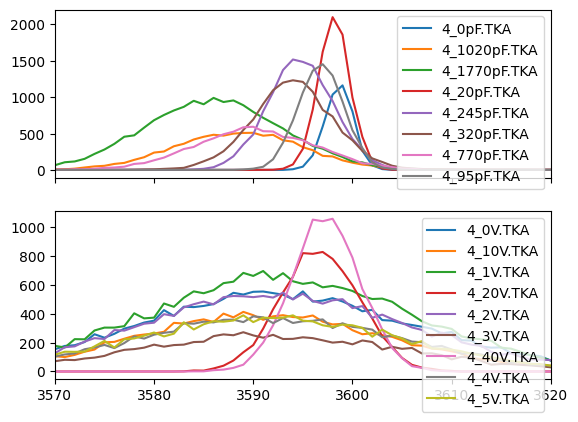

In [29]:
from scipy.optimize import curve_fit

def Gauss(x, mu, sig, A):
    return A*np.exp(-(x-mu)**2/(2*sig**2))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

for file in os.listdir(r'../Messdaten/19012026_Halbleiter/4_Rauschen/'):
    if len(file.split("_")) == 3:
        continue
    data = np.loadtxt(f'../Messdaten/19012026_Halbleiter/4_Rauschen/{file}')[2:]
    x = np.arange(3, 4097)
    guess = [3599, 10, 10]
    popt, pcov = curve_fit(Gauss, x, data, p0=guess)
    print(file, popt)

    if file.split("_")[1].split(".")[0][-1] == 'V':
        ax2.plot(x, data, label=file)
    else:
        ax1.plot(x, data, label=file)

ax2.set_xlim(3570, 3620)
ax1.legend(loc=1)
ax2.legend(loc=1)